In [9]:
from pydataxm.pydatasimem import ReadSIMEM
import pandas as pd
import seaborn as sns

# 1. Descargamos la Generación Real (Dataset ID: E17D25) para un periodo reciente
# Nota: Puedes ajustar estas fechas al último mes o semana que quieras analizar
fecha_inicio = '2024-04-01'
fecha_fin = '2024-04-30' 

print("Descargando datos de Generación Real...")
simem_gen = ReadSIMEM('E17D25', fecha_inicio, fecha_fin)
df_genreal = simem_gen.main()

# 2. Ahora sí, vemos las variables que trae el dataset
columnas = df_genreal.columns.tolist()
print("\n=== EXPLORACIÓN DE VARIABLES ===")
print("Columnas en el dataset:", columnas)

tipos_energia = df_genreal['TipoGeneracion'].unique().tolist()
print("Tipos de energía generando actualmente:", tipos_energia)

tipos_recurso = df_genreal['TipoDespachoRecurso'].unique().tolist()
print("Tipos de despacho:", tipos_recurso)

# 3. Transformamos (pivoteamos) los datos para agruparlos por día en GWh
df_genreal_tipo = df_genreal.groupby(['Fecha','TipoGeneracion'])['GeneracionRealEstimada'].sum().reset_index()
df_genreal_tipo['GeneracionRealEstimada'] = df_genreal_tipo['GeneracionRealEstimada'] / 1000000 # Convertir a GWh
df_genreal_tipo = df_genreal_tipo.pivot_table(columns='TipoGeneracion', index='Fecha', values='GeneracionRealEstimada', fill_value=0).reset_index()
df_genreal_tipo['Fecha'] = pd.to_datetime(df_genreal_tipo['Fecha'], format='%Y-%m-%d')

print("\n¡Datos preparados con éxito! df_genreal y df_genreal_tipo están en memoria.")

ModuleNotFoundError: No module named 'seaborn'

In [3]:
import pandas as pd

# 1. Ver las primeras y últimas filas para entender la estructura
print("=== PRIMERAS FILAS ===")
display(df_genreal.head())

# 2. Conocer las dimensiones (filas x columnas)
print(f"\nEl dataset tiene {df_genreal.shape[0]} filas y {df_genreal.shape[1]} columnas.")

# 3. Ver los tipos de datos y si hay valores nulos
print("\n=== INFORMACIÓN DE LAS COLUMNAS ===")
df_genreal.info()

# 4. Resumen estadístico rápido de las columnas numéricas (Generación en kWh)
print("\n=== RESUMEN ESTADÍSTICO ===")
display(df_genreal.describe().apply(lambda s: s.apply('{0:.2f}'.format))) # Formato legible

=== PRIMERAS FILAS ===


,Fecha,CodigoPlanta,TipoGeneracion,TipoClasificacion,TipoDespachoRecurso,GeneracionRealEstimada,GeneracionProgramadaDespacho,GeneracionProgramadaRedespacho
0,2024-04-30,3GRD,Solar,Solar,No Despachado Centralmente,65600.34,57000.0,57000.0
1,2024-04-30,3HWM,Solar,Solar,No Despachado Centralmente,83645.44,12000.0,12000.0
2,2024-04-30,3ENE,Solar,Solar,No Despachado Centralmente,131047.78,36000.0,36000.0
3,2024-04-30,3HLD,Solar,Solar,No Despachado Centralmente,43896.92,70840.0,70840.0
4,2024-04-30,3GVI,Solar,Solar,No Despachado Centralmente,155235.44,6000.0,6000.0



El dataset tiene 9762 filas y 8 columnas.

=== INFORMACIÓN DE LAS COLUMNAS ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9762 entries, 0 to 9761
Data columns (total 8 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Fecha                           9762 non-null   object 
 1   CodigoPlanta                    9762 non-null   object 
 2   TipoGeneracion                  9762 non-null   object 
 3   TipoClasificacion               9762 non-null   object 
 4   TipoDespachoRecurso             9762 non-null   object 
 5   GeneracionRealEstimada          9762 non-null   float64
 6   GeneracionProgramadaDespacho    9762 non-null   float64
 7   GeneracionProgramadaRedespacho  9762 non-null   float64
dtypes: float64(3), object(5)
memory usage: 610.3+ KB

=== RESUMEN ESTADÍSTICO ===


,GeneracionRealEstimada,GeneracionProgramadaDespacho,GeneracionProgramadaRedespacho
count,9762.00,9762.00,9762.00
mean,701254.59,694793.88,693441.74
std,2331520.91,2242654.46,2299517.29
min,0.00,0.00,0.00
25%,4167.22,6000.00,5890.00
50%,44982.24,50000.00,48000.00
75%,261013.54,276480.00,264000.00
max,25098476.00,25200000.00,25200000.00


In [4]:
print("=== ANÁLISIS DE CATEGORÍAS ===")

# 1. Tipos de Generación de Energía (La matriz energética)
tipos_energia = df_genreal['TipoGeneracion'].unique()
print(f"\nTipos de energía disponibles ({len(tipos_energia)}):")
print(tipos_energia)

# 2. Ver la cantidad de registros por cada tipo de energía
print("\nConteo de registros por tipo de energía:")
display(df_genreal['TipoGeneracion'].value_counts())

# 3. Tipos de Despacho (Centralizado vs No centralizado)
tipos_despacho = df_genreal['TipoDespachoRecurso'].unique()
print(f"\nTipos de despacho disponibles:")
print(tipos_despacho)

# 4. Agentes / Plantas Generadoras (Código de cada planta)
plantas = df_genreal['CodigoPlanta'].unique()
print(f"\nExisten {len(plantas)} plantas/agentes generadores distintos en este periodo.")
print("Ejemplo de 10 códigos de plantas:", plantas[:10])

=== ANÁLISIS DE CATEGORÍAS ===

Tipos de energía disponibles (5):
['Solar' 'Termica' 'Hidraulica' 'Eolica' 'Cogenerador']

Conteo de registros por tipo de energía:


TipoGeneracion
Hidraulica     4749
Solar          2533
Termica        2030
Cogenerador     360
Eolica           90
Name: count, dtype: int64


Tipos de despacho disponibles:
['No Despachado Centralmente' 'Despachado Centralmente']

Existen 330 plantas/agentes generadores distintos en este periodo.
Ejemplo de 10 códigos de plantas: ['3GRD' '3HWM' '3ENE' '3HLD' '3GVI' '3K6T' '3J4R' '3IS2' '3J2H' '3HF7']


In [5]:
print("=== AGRUPACIONES (GROUPBY) ===")

# 1. ¿Cuánta energía TOTAL se generó por cada tipo en este mes?
# Agrupamos por tipo de generación y sumamos, luego convertimos a GWh dividiendo por 1,000,000
gen_total_tecnologia = df_genreal.groupby('TipoGeneracion')['GeneracionRealEstimada'].sum() / 1000000
gen_total_tecnologia = gen_total_tecnologia.sort_values(ascending=False)

print("Generación Total por Tecnología (GWh) en el periodo:")
display(gen_total_tecnologia)

# 2. Agrupación doble: Por Fecha y por Tipo de Generación
# Esto es ideal para series de tiempo
serie_tiempo_gen = df_genreal.groupby(['Fecha', 'TipoGeneracion'])['GeneracionRealEstimada'].sum() / 1000000

# Convertimos ese resultado en una tabla pivote para ver mejor los datos diarios
df_pivote = serie_tiempo_gen.unstack(fill_value=0)
df_pivote.index = pd.to_datetime(df_pivote.index) # Asegurar formato de fecha

print("\nEvolución diaria de la generación (GWh):")
display(df_pivote.head())

=== AGRUPACIONES (GROUPBY) ===
Generación Total por Tecnología (GWh) en el periodo:


TipoGeneracion
Hidraulica     3307.665362
Termica        3190.094600
Solar           262.131685
Cogenerador      69.647357
Eolica           16.108282
Name: GeneracionRealEstimada, dtype: float64


Evolución diaria de la generación (GWh):


TipoGeneracion,Cogenerador,Eolica,Hidraulica,Solar,Termica
Fecha,,,,,
2024-04-01,2.214651,0.433633,117.223750,9.861246,102.354904
2024-04-02,2.160171,0.443939,117.813511,7.857762,101.570386
2024-04-03,2.358129,0.416975,117.142970,7.001703,104.479538
2024-04-04,2.222087,0.369173,117.444236,5.762751,104.918669
2024-04-05,2.050047,0.386227,123.198462,9.090898,102.559779


In [6]:
print("=== DATAFRAME BASE PARA FEATURE ENGINEERING ===")
# Configuramos pandas para ver todas las columnas si son muchas
pd.set_option('display.max_columns', None)

# Vemos la estructura actual
display(df_genreal_tipo.head())
display(df_genreal_tipo.tail())

# Revisamos si hay algún valor nulo que debamos imputar antes de crear features
print("\nValores nulos por columna:")
print(df_genreal_tipo.isnull().sum())

=== DATAFRAME BASE PARA FEATURE ENGINEERING ===


TipoGeneracion,Fecha,Cogenerador,Eolica,Hidraulica,Solar,Termica
0,2024-04-01,2.214651,0.433633,117.223750,9.861246,102.354904
1,2024-04-02,2.160171,0.443939,117.813511,7.857762,101.570386
2,2024-04-03,2.358129,0.416975,117.142970,7.001703,104.479538
3,2024-04-04,2.222087,0.369173,117.444236,5.762751,104.918669
4,2024-04-05,2.050047,0.386227,123.198462,9.090898,102.559779


TipoGeneracion,Fecha,Cogenerador,Eolica,Hidraulica,Solar,Termica
25,2024-04-26,2.124874,0.506849,99.411627,5.688622,116.872792
26,2024-04-27,2.143355,0.530333,101.768788,8.260937,104.462124
27,2024-04-28,2.117363,0.392625,88.511828,7.198013,95.968959
28,2024-04-29,1.668740,0.423793,141.568928,8.533306,70.159774
29,2024-04-30,1.570831,0.460448,143.257230,10.122348,78.447308



Valores nulos por columna:
TipoGeneracion
Fecha          0
Cogenerador    0
Eolica         0
Hidraulica     0
Solar          0
Termica        0
dtype: int64


In [7]:
# Hacemos una copia para no alterar el original
df_features = df_genreal_tipo.copy()

print("=== 1. FEATURES TEMPORALES ===")
# Extraemos componentes de la fecha
df_features['DiaSemana'] = df_features['Fecha'].dt.dayofweek # Lunes=0, Domingo=6
df_features['Mes'] = df_features['Fecha'].dt.month
df_features['DiaDelMes'] = df_features['Fecha'].dt.day

# Variable binaria: ¿Es fin de semana? (Sábado o Domingo)
df_features['EsFinSemana'] = df_features['DiaSemana'].isin([5, 6]).astype(int)

print("=== 2. FEATURES DE REZAGO (LAGS) ===")
# ¿Cuánta energía térmica se generó AYER? (lag de 1 día)
df_features['Termica_Lag1'] = df_features['Termica'].shift(1)

# ¿Cuánta energía hidráulica se generó hace una semana? (lag de 7 días)
df_features['Hidraulica_Lag7'] = df_features['Hidraulica'].shift(7)

print("=== 3. FEATURES DE VENTANA MÓVIL (ROLLING WINDOWS) ===")
# Promedio móvil de los últimos 3 días para suavizar picos en la generación solar
df_features['Solar_Media3Dias'] = df_features['Solar'].rolling(window=3).mean()

# Desviación estándar de los últimos 7 días de generación térmica (mide la volatilidad)
df_features['Termica_Std7Dias'] = df_features['Termica'].rolling(window=7).std()

print("=== 4. FEATURES DE INTERACCIÓN (RATIOS) ===")
# Ratio de Térmica vs Hidráulica (Un indicador clave de escasez/Fenómeno del Niño)
# Sumamos 0.001 para evitar divisiones por cero
df_features['Ratio_Termica_Hidro'] = df_features['Termica'] / (df_features['Hidraulica'] + 0.001)

# Eliminamos las filas que quedaron con NaN debido a los Lags y Rolling Windows
df_features.dropna(inplace=True)

print("\n¡Feature Engineering completado! Así se ve tu nuevo DataFrame:")
display(df_features.head())

=== 1. FEATURES TEMPORALES ===
=== 2. FEATURES DE REZAGO (LAGS) ===
=== 3. FEATURES DE VENTANA MÓVIL (ROLLING WINDOWS) ===
=== 4. FEATURES DE INTERACCIÓN (RATIOS) ===

¡Feature Engineering completado! Así se ve tu nuevo DataFrame:


TipoGeneracion,Fecha,Cogenerador,Eolica,Hidraulica,Solar,Termica,DiaSemana,Mes,DiaDelMes,EsFinSemana,Termica_Lag1,Hidraulica_Lag7,Solar_Media3Dias,Termica_Std7Dias,Ratio_Termica_Hidro
7,2024-04-08,2.483003,0.630682,117.607645,9.090189,106.217906,0,4,8,0,90.624715,117.223750,9.742058,6.207317,0.903147
8,2024-04-09,2.390853,0.684087,116.360857,9.504196,106.760035,1,4,9,0,106.217906,117.813511,9.637405,6.657810,0.917483
9,2024-04-10,2.643861,0.675700,116.602332,10.465967,109.584173,2,4,10,0,106.760035,117.142970,9.686784,7.324869,0.939803
10,2024-04-11,2.541975,0.634153,117.719619,10.182969,112.575508,3,4,11,0,109.584173,117.444236,10.051044,8.348393,0.956294
11,2024-04-12,2.584482,0.673916,114.770101,10.998915,113.217575,4,4,12,0,112.575508,123.198462,10.549283,9.183024,0.986464


  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)

[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


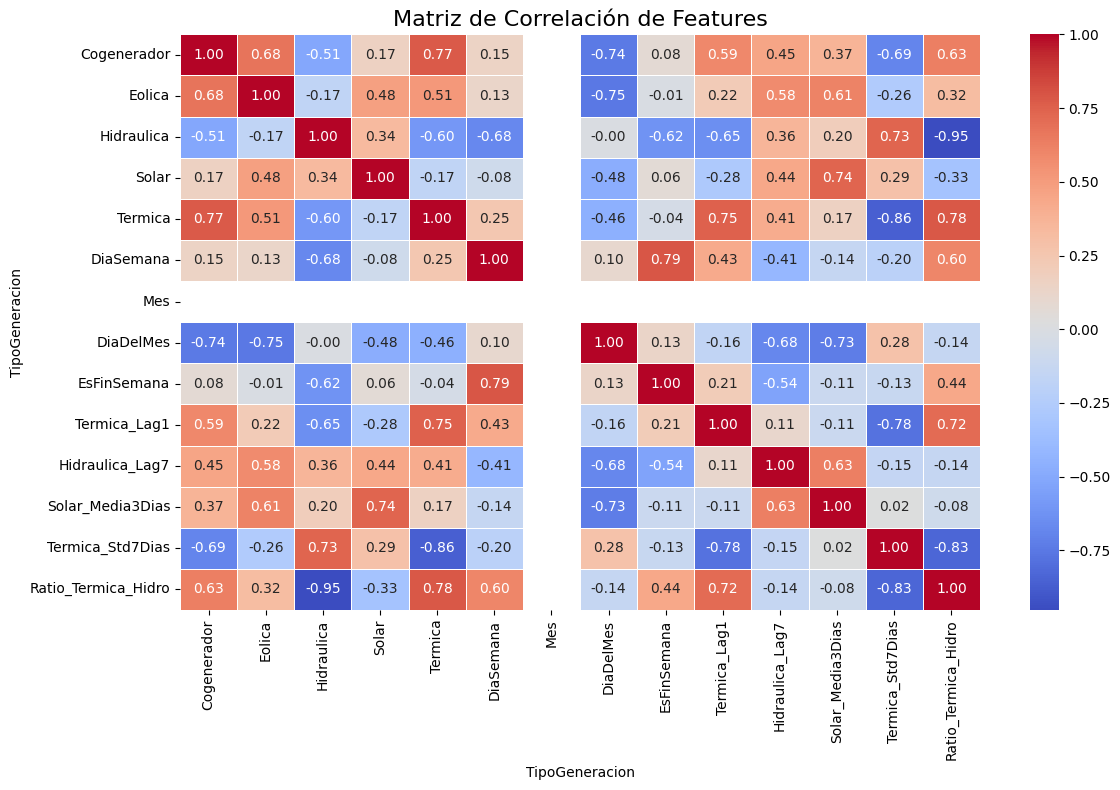

In [11]:
# Instalamos la librería faltante directamente desde Jupyter
!pip install seaborn

import seaborn as sns
import matplotlib.pyplot as plt

# Seleccionamos solo las columnas numéricas para la correlación
columnas_numericas = df_features.select_dtypes(include=['float64', 'int64', 'int32']).columns
df_corr = df_features[columnas_numericas].corr()

plt.figure(figsize=(12, 8))
# Heatmap de correlación
sns.heatmap(df_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación de Features', fontsize=16)
plt.tight_layout()
plt.show()

In [14]:
from pydataxm.pydatasimem import CatalogSIMEM
import pandas as pd

# Inicializamos el catálogo
catalogo = CatalogSIMEM('Datasets').get_data()
pd.set_option('display.max_colwidth', None)

# Búsqueda amplia de palabras clave
res_volumen = catalogo[catalogo['nombreConjuntoDatos'].str.contains('Volumen', case=False, na=False)]
res_capacidad = catalogo[catalogo['nombreConjuntoDatos'].str.contains('Capacidad', case=False, na=False)]
res_embalse = catalogo[catalogo['nombreConjuntoDatos'].str.contains('Embalse', case=False, na=False)]

print("=== DATASETS CON LA PALABRA 'VOLUMEN' ===")
display(res_volumen[['idDataset', 'nombreConjuntoDatos']])

print("\n=== DATASETS CON LA PALABRA 'CAPACIDAD' ===")
display(res_capacidad[['idDataset', 'nombreConjuntoDatos']])

print("\n=== DATASETS CON LA PALABRA 'EMBALSE' ===")
display(res_embalse[['idDataset', 'nombreConjuntoDatos']])

=== DATASETS CON LA PALABRA 'VOLUMEN' ===


,idDataset,nombreConjuntoDatos



=== DATASETS CON LA PALABRA 'CAPACIDAD' ===


,idDataset,nombreConjuntoDatos
84,FADED0,Capacidad efectiva neta por planta en potencia
180,7E9CBB,Capacidad de respaldo para operaciones en el Mercado Mayorista de Energía
349,43cd59,Garantía de reserva de capacidad de transporte
364,8d7548,Garantía de reserva de capacidad de transporte



=== DATASETS CON LA PALABRA 'EMBALSE' ===


,idDataset,nombreConjuntoDatos
5,7AEE6F,Nivel embalse reportado menos compromisos EVE embalsados por planta
11,8d3ccd,Proyección de embalse agregado de corto plazo
38,37A508,Panorama energético Corto Plazo Embalse
61,A0CF2A,Listado de Embalses que sirven al Sistema Interconectado Nacional
116,71a7b9,Niveles Mínimos Operativos de Embalses de invierno
130,bd583d,Niveles Mínimos Operativos de Embalses de verano
262,BD26DC,Nivel de embalse declarado por el agente diariamente


In [15]:
from pydataxm.pydatasimem import CatalogSIMEM
import pandas as pd

# Descargamos TODO el catálogo
catalogo_obj = CatalogSIMEM('Datasets')
df_completo = catalogo_obj.get_data()

# Configuramos para leer bien los nombres largos
pd.set_option('display.max_colwidth', None)

print(f"Total de datasets encontrados: {len(df_completo)}")
# Mostramos los primeros 20 para entender qué hay
display(df_completo[['idDataset', 'nombreConjuntoDatos', 'inicioDato', 'finDato']].head(20))

# Tip: Si quieres buscar algo específico, usa esta línea:
# display(df_completo[df_completo['nombreConjuntoDatos'].str.contains('Aportes', case=False)])

Total de datasets encontrados: 376


,idDataset,nombreConjuntoDatos,inicioDato,finDato
0,a704ee,"Datos soporte del proceso de liquidación por Código sic agente, Recurso, Tipo combustible, versión y mensual",2017-12-01T00:00:00,2025-12-01T00:00:00
1,d808d4,Energía de Referencia para el Mercado Secundario,2018-12-01T00:00:00,2050-11-30T00:00:00
2,2106b8,Precios y estadísticas de los contratos de convocatorias del SICEP entre agentes integrados verticalmente para el mercado regulado por comercializador,2020-10-01T00:00:00,2026-01-01T00:00:00
3,B1009C,Compras en bolsa nacional en moneda,2021-01-01T00:00:00,2026-02-27T00:00:00
4,E4CE10,Costo Servicios ASIC y CND,2021-01-01T00:00:00,2026-01-01T00:00:00
5,7AEE6F,Nivel embalse reportado menos compromisos EVE embalsados por planta,2021-01-01T00:00:00,2026-02-28T00:00:00
6,F3A83B,Estadísticas de contratos de Demanda Desconectable Voluntaria (DDV),2022-12-01T00:00:00,2026-11-01T00:00:00
7,bf41fe,Histórico Posición abierta por contrato II Open interest II,2023-08-31T00:00:00,2026-01-31T00:00:00
8,ae3f23,Precios de escasez del Cargo por Confiabilidad,2013-01-01T00:00:00,2026-02-01T00:00:00
9,5106B9,Declaración de respaldo horaria para cada planta y/o unidad,2021-01-01T00:00:00,2026-01-05T00:00:00


In [16]:
# Ejemplo de cómo se vería tu data lista para el modelo
# df_final = pd.merge(...) cruce de todas las variables anteriores

features_escasez = [
    'PrecBolsNaci',       # Objetivo
    'Nivel_Embalse',      # Estado de la reserva
    'Pct_Termica',        # Costo de generación actual
    'Demanda_Total',      # Presión del mercado
    'Aportes_Media_7D'    # Tendencia de lluvias (Ingeniería de datos)
]

print("Variables organizadas para entrenamiento multivariable:")
# display(df_final[features_escasez].head())

Variables organizadas para entrenamiento multivariable:


In [19]:
from pydataxm.pydatasimem import ReadSIMEM
import pandas as pd
import numpy as np

# 1. Definir parámetros
fecha_inicio = '2024-04-01'
fecha_fin = '2024-04-30'
id_precio = 'EC6945'
id_generacion = 'E17D25'

print("Descargando Precio de Bolsa...")
df_precio_raw = ReadSIMEM(id_precio, fecha_inicio, fecha_fin).main()

print("Descargando Generación Real...")
df_gen_raw = ReadSIMEM(id_generacion, fecha_inicio, fecha_fin).main()

# 2. Procesar Precio (Limpiar versiones y filtrar PB_Nal)
df_precio = df_precio_raw[df_precio_raw['CodigoVariable'] == 'PB_Nal'].copy()
df_precio = df_precio.sort_values(['FechaHora', 'Version']).drop_duplicates(subset=['FechaHora'], keep='last')
df_precio = df_precio[['FechaHora', 'Valor']].rename(columns={'Valor': 'PrecBolsNaci'})
df_precio['FechaHora'] = pd.to_datetime(df_precio['FechaHora'])

# 3. Procesar Generación (Pivote de tecnologías)
df_gen = df_gen_raw.groupby(['Fecha', 'TipoGeneracion'])['GeneracionRealEstimada'].sum().reset_index()
df_gen['GeneracionRealEstimada'] = df_gen['GeneracionRealEstimada'] / 1000000 # a GWh
df_gen_pivote = df_gen.pivot_table(columns='TipoGeneracion', index='Fecha', values='GeneracionRealEstimada', fill_value=0).reset_index()
df_gen_pivote.rename(columns={'Fecha': 'Fecha_Dia', 'Termica': 'Gen_Termica', 'Hidraulica': 'Gen_Hidraulica'}, inplace=True)
df_gen_pivote['Fecha_Dia'] = pd.to_datetime(df_gen_pivote['Fecha_Dia'])

# 4. Consolidar df_dl (Unir Precio horario con Generación diaria)
# Extraemos el día del precio para poder unir con la generación
df_precio['Fecha_Dia'] = df_precio['FechaHora'].dt.normalize()

df_dl = pd.merge(df_precio, df_gen_pivote, on='Fecha_Dia', how='inner')
df_dl.set_index('FechaHora', inplace=True)

# Seleccionamos las variables clave para tu modelo del PDF
df_dl = df_dl[['PrecBolsNaci', 'Gen_Termica', 'Gen_Hidraulica']].dropna()

print(f"\n¡Éxito! Dataset consolidado. Forma: {df_dl.shape}")
display(df_dl.head(3))

Descargando Precio de Bolsa...
****************************************************************************************************
Initializing object
The object has been initialized with the dataset: "Precio de bolsa horario"
****************************************************************************************************
Inicio consulta sincronica
Creacion url: 0.0014290809631347656
Extraccion de registros: 6.027357816696167
End of data extracting process
****************************************************************************************************
Descargando Generación Real...
****************************************************************************************************
Initializing object
The object has been initialized with the dataset: "Generación Real y Programada en las Plantas de Generación"
****************************************************************************************************
Inicio consulta sincronica
Creacion url: 0.0002701282501220703
Extracc

,PrecBolsNaci,Gen_Termica,Gen_Hidraulica
FechaHora,,,
2024-04-01 00:00:00,767.4931,102.354904,117.22375
2024-04-01 01:00:00,767.4931,102.354904,117.22375
2024-04-01 02:00:00,767.4931,102.354904,117.22375


In [20]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# 1. Normalización
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df_dl)

# 2. Creación de ventanas (Look-back 48h -> Horizon 24h)
def create_sequences(data, look_back=48, horizon=24):
    X, y = [], []
    for i in range(len(data) - look_back - horizon + 1):
        X.append(data[i : i + look_back]) # Entrada: Precio, Térmica, Hidro
        y.append(data[i + look_back : i + look_back + horizon, 0]) # Salida: Solo Precio
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data)

# Dividir en Train (80%) y Test (20%)
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

print(f"X_train shape: {X_train.shape} (Muestras, Horas de historia, Variables)")


X_train shape: (519, 48, 3) (Muestras, Horas de historia, Variables)


In [21]:
model = Sequential([
    GRU(50, return_sequences=False, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    Dense(24) # Predice las 24 horas del día siguiente
])

model.compile(optimizer='adam', loss='mse')

# Parada temprana para optimizar el tiempo
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

print("Iniciando entrenamiento...")
history = model.fit(
    X_train, y_train,
    epochs=50,
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

Iniciando entrenamiento...
Epoch 1/50


/Users/feliperuizzea/Documents/3.Proyectos_programacion/test_energia/env_energia/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.4258 - val_loss: 0.0295
Epoch 2/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1628 - val_loss: 0.1374
Epoch 3/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0733 - val_loss: 0.1155
Epoch 4/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0601 - val_loss: 0.1019
Epoch 5/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0539 - val_loss: 0.0843
Epoch 6/50
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0510 - val_loss: 0.0669


In [22]:
# Predicción
y_pred_scaled = model.predict(X_test)

# Inversión manual del escalado para el Precio (columna 0)
min_p, max_p = scaler.data_min_[0], scaler.data_max_[0]
y_test_rescaled = y_test * (max_p - min_p) + min_p
y_pred_rescaled = y_pred_scaled * (max_p - min_p) + min_p

# Cálculo de métricas
mae = np.mean(np.abs(y_test_rescaled - y_pred_rescaled))
mape = np.mean(np.abs((y_test_rescaled - y_pred_rescaled) / y_test_rescaled)) * 100

print(f"\n--- RESULTADOS DEL MODELO ---")
print(f"MAE: {mae:.2f} COP/kWh")
print(f"MAPE: {mape:.2f}%")

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step

--- RESULTADOS DEL MODELO ---
MAE: 162.63 COP/kWh
MAPE: 116.34%


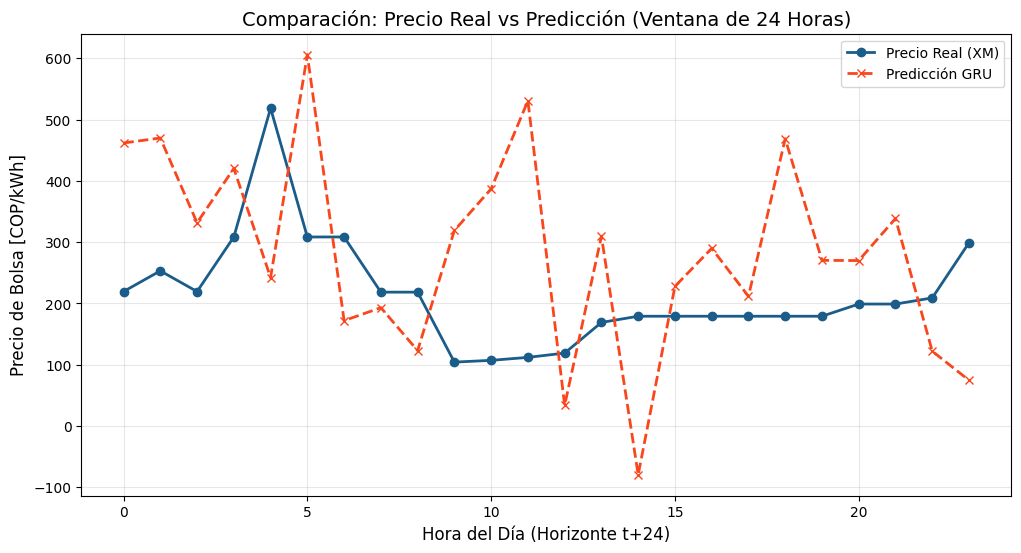

In [23]:
import matplotlib.pyplot as plt

# Seleccionamos una muestra al azar del set de test (por ejemplo, la primera ventana de 24h)
idx = 0 

plt.figure(figsize=(12, 6))
plt.plot(y_test_rescaled[idx], label='Precio Real (XM)', color='#1A5C8A', linewidth=2, marker='o')
plt.plot(y_pred_rescaled[idx], label='Predicción GRU', color='#F9461C', linestyle='--', linewidth=2, marker='x')

plt.title('Comparación: Precio Real vs Predicción (Ventana de 24 Horas)', fontsize=14)
plt.xlabel('Hora del Día (Horizonte t+24)', fontsize=12)
plt.ylabel('Precio de Bolsa [COP/kWh]', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [29]:
from pydataxm.pydatasimem import ReadSIMEM, CatalogSIMEM
import pandas as pd
import numpy as np

# 1. Obtener catálogo y buscar IDs
catalogo = CatalogSIMEM('Datasets').get_data()

def buscar_id(nombre_busqueda):
    resultado = catalogo[catalogo['nombreConjuntoDatos'].str.contains(nombre_busqueda, case=False, na=False)]
    return resultado.iloc[0]['idDataset']

id_precio = 'EC6945'
id_generacion = buscar_id('Generación Real y Programada en las Plantas')
id_embalse = buscar_id('Nivel de embalse declarado por el agente diariamente')

# 2. Configuración y Descarga
fecha_inicio, fecha_fin = '2024-01-01', '2024-04-30'
print("Descargando datos del SiMEM...")
df_p_raw = ReadSIMEM(id_precio, fecha_inicio, fecha_fin).main()
df_g_raw = ReadSIMEM(id_generacion, fecha_inicio, fecha_fin).main()
df_e_raw = ReadSIMEM(id_embalse, fecha_inicio, fecha_fin).main()

# FUNCIÓN AUXILIAR para encontrar la columna de fecha sin importar el nombre
def fix_date_col(df):
    for col in df.columns:
        if 'fecha' in col.lower():
            df[col] = pd.to_datetime(df[col])
            return col
    return None

# 3. Procesamiento de Precio
col_p = fix_date_col(df_p_raw)
df_p = df_p_raw[df_p_raw['CodigoVariable'] == 'PB_Nal'].copy()
df_p = df_p.sort_values([col_p, 'Version']).drop_duplicates(subset=[col_p], keep='last')
df_p = df_p[[col_p, 'Valor']].rename(columns={col_p: 'FechaHora', 'Valor': 'Precio'})

# 4. Procesamiento de Generación
col_g = fix_date_col(df_g_raw)
df_g = df_g_raw.groupby([col_g, 'TipoGeneracion'])['GeneracionRealEstimada'].sum().reset_index()
df_g_piv = df_g.pivot_table(index=col_g, columns='TipoGeneracion', values='GeneracionRealEstimada', fill_value=0)
df_g_piv = df_g_piv[['Hidraulica', 'Termica']] / 1e6

# 5. Procesamiento de Embalses
col_e = fix_date_col(df_e_raw)
df_e = df_e_raw.groupby(col_e)['Valor'].sum().to_frame().rename(columns={'Valor': 'Nivel_Embalse'})

# 6. UNIÓN MAESTRA (Merge)
df_p['Fecha_Dia'] = df_p['FechaHora'].dt.normalize()
df_master = df_p.merge(df_g_piv, left_on='Fecha_Dia', right_index=True, how='inner')
df_master = df_master.merge(df_e, left_on='Fecha_Dia', right_index=True, how='inner')
df_master.set_index('FechaHora', inplace=True)

# 7. Ingeniería de Características (Features)
df_master['Hora'] = df_master.index.hour
df_master['Ratio_Termico'] = df_master['Termica'] / (df_master['Hidraulica'] + 1)
df_master.drop(columns=['Fecha_Dia'], inplace=True)

print(f"\n¡Dataset Maestro Integrado! Columnas: {df_master.columns.tolist()}")
display(df_master.head())

Descargando datos del SiMEM...
****************************************************************************************************
Initializing object
The object has been initialized with the dataset: "Precio de bolsa horario"
****************************************************************************************************
Inicio consulta sincronica
Creacion url: 0.0014889240264892578
Extraccion de registros: 9.261766910552979
End of data extracting process
****************************************************************************************************
****************************************************************************************************
Initializing object
The object has been initialized with the dataset: "Generación Real y Programada en las Plantas de Generación"
****************************************************************************************************
Inicio consulta sincronica
Creacion url: 0.0006859302520751953
Extraccion de registros: 9.31574201583

,Precio,Hidraulica,Termica,Nivel_Embalse,Hora,Ratio_Termico
FechaHora,,,,,,
2024-01-01 00:00:00,251.4471,143.842058,25.116513,6.110558e+10,0,0.173406
2024-01-01 01:00:00,251.4471,143.842058,25.116513,6.110558e+10,1,0.173406
2024-01-01 02:00:00,251.4471,143.842058,25.116513,6.110558e+10,2,0.173406
2024-01-01 03:00:00,251.4471,143.842058,25.116513,6.110558e+10,3,0.173406
2024-01-01 04:00:00,281.4471,143.842058,25.116513,6.110558e+10,4,0.173406


In [30]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# 1. Preparación de datos multivariable
# Usamos todas las columnas del df_master
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(df_master)

# 2. Creación de secuencias (Ventana de 48h para predecir 24h)
def create_sequences(data, look_back=48, horizon=24):
    X, y = [], []
    for i in range(len(data) - look_back - horizon + 1):
        X.append(data[i : i + look_back]) # Entrada: Las 6 variables
        y.append(data[i + look_back : i + look_back + horizon, 0]) # Salida: Solo Precio (Col 0)
    return np.array(X), np.array(y)

X, y = create_sequences(scaled_data)

# Split 80/20
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# 3. Definición de la Red Neuronal (Arquitectura de tu estudio)
model = Sequential([
    GRU(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),
    GRU(32, return_sequences=False),
    Dropout(0.2),
    Dense(24) # 24 horas del horizonte de predicción
])

model.compile(optimizer='adam', loss='mse')

# 4. Entrenamiento
early_stop = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)

print(f"Iniciando entrenamiento con {X_train.shape[0]} muestras...")
history = model.fit(
    X_train, y_train,
    epochs=100, # Más épocas porque hay más variables que aprender
    batch_size=32,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
    verbose=1
)

# 5. Evaluación del error (MAPE)
y_pred_scaled = model.predict(X_test)
min_p, max_p = scaler.data_min_[0], scaler.data_max_[0]
y_test_real = y_test * (max_p - min_p) + min_p
y_pred_real = y_pred_scaled * (max_p - min_p) + min_p

mape = np.mean(np.abs((y_test_real - y_pred_real) / y_test_real)) * 100
print(f"\n✅ MAPE Final: {mape:.2f}%")


Iniciando entrenamiento con 2266 muestras...
Epoch 1/100


/Users/feliperuizzea/Documents/3.Proyectos_programacion/test_energia/env_energia/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 0.0558 - val_loss: 0.0665
Epoch 2/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0185 - val_loss: 0.0242
Epoch 3/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0137 - val_loss: 0.0211
Epoch 4/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0117 - val_loss: 0.0199
Epoch 5/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0104 - val_loss: 0.0196
Epoch 6/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0092 - val_loss: 0.0200
Epoch 7/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0089 - val_loss: 0.0222
Epoch 8/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0084 - val_loss: 0.0188
Epoch 9/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0078 - val_loss: 0.0195
Epoch 10/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 0.0075 - val_loss: 0.0205
Epoch 11/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0072 - val_loss: 0.0194
Epoch 12/100
71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0

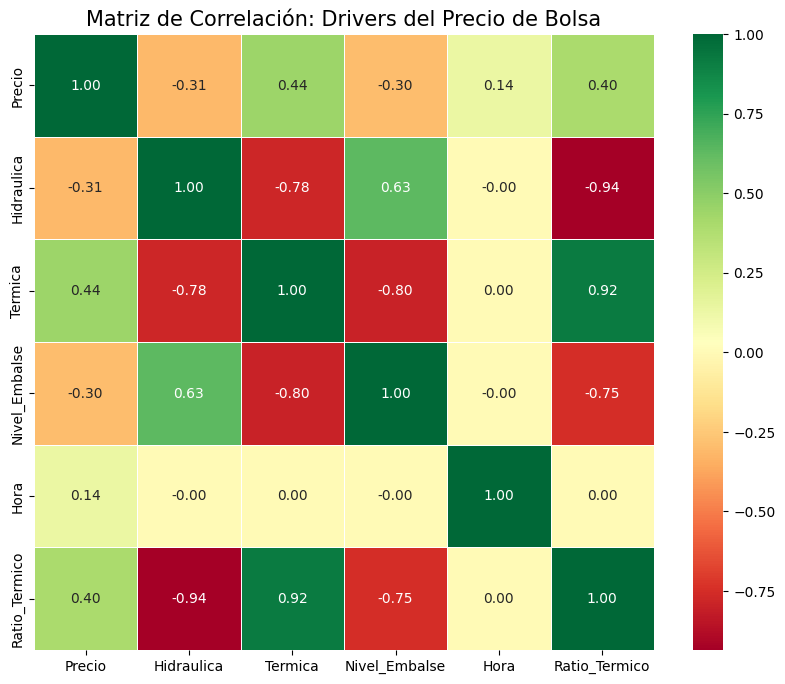

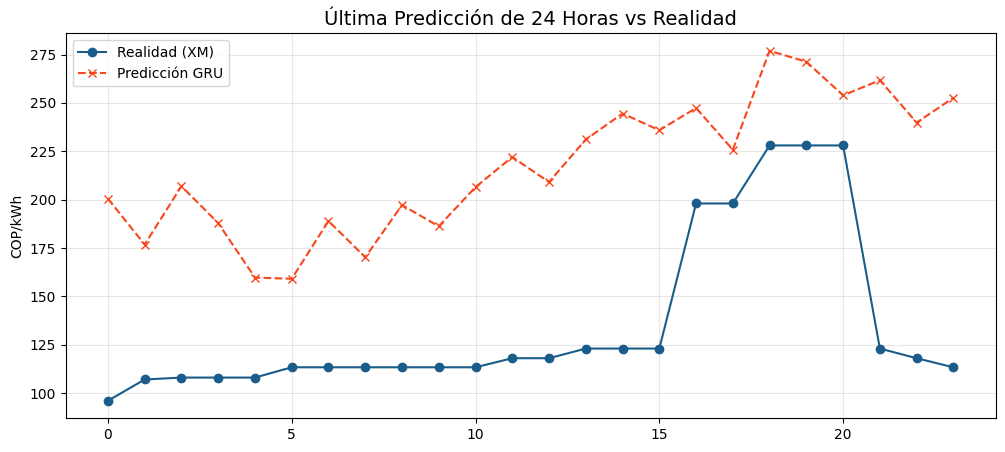

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculamos la correlación en el DataFrame maestro
df_corr = df_master.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(df_corr, annot=True, cmap='RdYlGn', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación: Drivers del Precio de Bolsa', fontsize=15)
plt.show()

# 2. Visualización de la última predicción del set de Test
plt.figure(figsize=(12, 5))
plt.plot(y_test_real[-1], label='Realidad (XM)', color='#1A5C8A', marker='o')
plt.plot(y_pred_real[-1], label='Predicción GRU', color='#F9461C', linestyle='--', marker='x')
plt.title('Última Predicción de 24 Horas vs Realidad', fontsize=14)
plt.ylabel('COP/kWh')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
